In [1]:
using ScQubitsMimic
using CairoMakie
using Latexify
using Markdown

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

# Tunable Custom Circuit Analysis

This notebook follows the pedagogical flow of scqubits `demo_customcircuit.ipynb`, but applies it to the grounded Yan-style tunable-coupler circuit currently supported in `ScQubitsMimic.jl`.

The physical system is not the scqubits `0-π` circuit. Instead, we study a three-loop grounded circuit with left-qubit, coupler, and right-qubit SQUID loops. The model used here now includes a weak direct capacitor `C12` between nodes `1` and `3`; because this repo parameterizes `C` branches by `EC`, that weak physical capacitance is represented by a large branch value `EC=500.0`, much weaker than `C1c` and `C2c` at `EC=5.0`. Supported symbolic, configured-subsystem, and direct-diagonalization APIs are arranged in the same order as the scqubits tutorial, and the remaining differences versus the scqubits walkthrough are called out explicitly below.


## Capability Audit

This notebook now covers the custom-circuit features that were previously missing from the repo's scqubits-style walkthrough:

- symbolic Lagrangian inspection in both node and transformed-variable form via `sym_lagrangian(...; vars_type=:node/:new)`
- external-flux loop mapping via `sym_external_fluxes(circ)`
- periodic-mode offset-charge inspection via `offset_charges(circ)` and node-to-mode mapping via `offset_charge_transformation(circ)`
- scqubits-style per-mode cutoff controls via `cutoff_names`, `cutoff_n_i`, and `cutoff_ext_i`
- configured subsystem introspection via `configure!`, `sym_hamiltonian(...; subsystem_index=...)`, and `sym_interaction(...; subsystem_indices=(i, j, ...))`
- subsystem-resolved hierarchical sweeps via `hierarchical_diag(...)`

In Julia, `configure!` is the stateful equivalent of scqubits `configure(...)`.

The remaining gaps highlighted in this notebook are limited to `Circuit`-level visualization helpers such as `plot_potential` and circuit wavefunction plots.


## Circuit Information and Define Circuit

The YAML description below builds a grounded three-node circuit. The three superconducting loops will later be identified with `Φ1` (left qubit), `Φ2` (middle coupler), and `Φ3` (right qubit).


In [ ]:
tcap_coupled_tmon = """
branches:
  - [JJ, 0, 1, EJ=4.5, EC=0.1]
  - [JJ, 1, 0, EJ=10.5, EC=0.1]
  - [C, 1, 0, EC=0.2]
  - [C, 1, 2, EC=5.0]
  - [JJ, 0, 2, EJ=30.0, EC=0.1]
  - [JJ, 2, 0, EJ=20.0, EC=0.1]
  - [C, 2, 0, EC=0.1]
  - [C, 2, 3, EC=5.0]
  - [JJ, 0, 3, EJ=4.6, EC=0.1]
  - [JJ, 3, 0, EJ=10.0, EC=0.1]
  - [C, 3, 0, EC=0.2]
  - [C, 1, 3, EC=500.0]
"""

circ1 = Circuit(tcap_coupled_tmon; ncut=6)


In [ ]:
cg = parse_circuit(tcap_coupled_tmon)
tree = find_spanning_tree(cg)
closure = find_closure_branches(cg, tree)
closure_sc, loops_sc = find_superconducting_loops(cg)
floops = find_fundamental_loops(cg, tree)

println(tree)        # [3, 4, 8]
println(closure)     # includes weak C12 as branch 12
println(closure_sc)  # unchanged: superconducting closure branches only
println(loops_sc)    # unchanged: superconducting loops only
println(floops)      # gains [(12, 1), (4, -1), (8, -1)] for the weak capacitive loop


[3, 4, 8]
[1, 2, 5, 6, 7, 9, 10, 11, 12]
[2, 6, 10]
[[(2, 1), (1, 1)], [(6, 1), (5, 1)], [(10, 1), (9, 1)]]
[[(1, 1), (3, 1)], [(2, 1), (3, -1)], [(5, 1), (3, 1), (4, -1)], [(6, 1), (4, 1), (3, -1)], [(7, 1), (4, 1), (3, -1)], [(9, 1), (3, 1), (4, -1), (8, -1)], [(10, 1), (8, 1), (4, 1), (3, -1)], [(11, 1), (8, 1), (4, 1), (3, -1)], [(12, 1), (4, -1), (8, -1)]]


## Lagrangian and Variable Transformation

We first inspect the symbolic Lagrangian in the node basis, then compare it with the transformed-variable basis used internally for classification and quantization.


**Lagrangian in terms of node variables**


In [ ]:
sym_lagrangian(circ1; vars_type=:node)


**Transformation between node variables and new variables**


In [4]:
variable_transformation(circ1)


([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0], VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]))

In [5]:
circ1.transformation_matrix # 이 경우 3개 다 "periodic variable" 


3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

**Types of the transformed variables**


In [6]:
circ1.var_categories


VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])

**Lagrangian in terms of new variables**


In [ ]:
sym_lagrangian(circ1; vars_type=:new)


## Hamiltonian and Diagonalization

At the moment this grounded Yan-style circuit is classified as three periodic modes and no extended modes, so each mode is quantized in the charge basis `|n⟩` with `n = -ncut:ncut`. For the main analysis object `circ1` we use `ncut = 6`, giving `2*ncut + 1 = 13` basis states per mode and a global direct-diagonalization Hilbert-space dimension of `13^3 = 2197`. The numerical engine does not introduce a subsystem hierarchy here; instead it constructs the full circuit Hamiltonian in that tensor-product charge basis and directly diagonalizes it to obtain the low-lying eigenspectrum. The coupler-flux sweep below repeats that same full direct diagonalization at each `Φ2` bias point.


**Symbolic Hamiltonian**


In [ ]:
sym_hamiltonian_node(circ1)


In [ ]:
sym_hamiltonian(circ1)


## Configured Subsystem Introspection

`configure!` stores a subsystem hierarchy on the `Circuit`, making it possible to inspect subsystem-resolved symbolic Hamiltonians and subsystem-set symbolic couplings without manually unpacking the hierarchical-diagonalization result.

Here we configure the three periodic modes as `QB1`, `CPLR`, and `QB2`. `sym_hamiltonian(...; subsystem_index=...)` returns the symbolic Hamiltonian for one configured subsystem, while `sym_interaction(...; subsystem_indices=(i, j, ...))` returns symbolic interaction terms whose involved subsystem-index set matches the requested tuple (order-insensitive).


In [10]:
function display_latex_entries(entries)
    for (label, expr) in entries
        display(Markdown.parse("**$(label)**"))
        display(latexify(expr))
    end
    nothing
end


display_latex_entries (generic function with 1 method)

In [ ]:
circ_cfg = Circuit(tcap_coupled_tmon; ncut=6)
set_param!(circ_cfg, :Φ1, 0.0)
set_param!(circ_cfg, :Φ2, 0.0)
set_param!(circ_cfg, :Φ3, 0.0)

configure!(circ_cfg;
    system_hierarchy=[[1], [2], [3]],
    subsystem_trunc_dims=[3, 3, 3])


In [12]:
subsystem_exprs = [
    "QB1" => sym_hamiltonian(circ_cfg; subsystem_index=1),
    "CPLR" => sym_hamiltonian(circ_cfg; subsystem_index=2),
    "QB2" => sym_hamiltonian(circ_cfg; subsystem_index=3),
]
display_latex_entries(subsystem_exprs)


**QB1**


L"\begin{equation}
 - 4.5 ~ \cos\left( \mathtt{\theta{_1}} \right) - 10.5 ~ \cos\left( \mathtt{{\Phi}1} - \mathtt{\theta{_1}} \right) + 0.63495 ~ \mathtt{n\theta{_1}}^{2}
\end{equation}
"

**CPLR**


L"\begin{equation}
 - 30 ~ \cos\left( \mathtt{\theta{_2}} \right) - 20 ~ \cos\left( \mathtt{{\Phi}2} - \mathtt{\theta{_2}} \right) + 0.52637 ~ \mathtt{n\theta{_2}}^{2}
\end{equation}
"

**QB2**


L"\begin{equation}
 - 4.6 ~ \cos\left( \mathtt{\theta{_3}} \right) - 10 ~ \cos\left( \mathtt{{\Phi}3} - \mathtt{\theta{_3}} \right) + 0.63495 ~ \mathtt{n\theta{_3}}^{2}
\end{equation}
"

In [ ]:
interaction_exprs = [
    "QB1-CPLR" => sym_interaction(circ_cfg; subsystem_indices=(1, 2), return_expr=true),
    "CPLR-QB2" => sym_interaction(circ_cfg; subsystem_indices=(2, 3), return_expr=true),
    "QB1-QB2" => sym_interaction(circ_cfg; subsystem_indices=(1, 3), return_expr=true),
]
display_latex_entries(interaction_exprs)

**Interaction interpretation**

With the weak direct `C12` branch included, `sym_interaction(circ_cfg; subsystem_indices=(1, 3))` is no longer only the effective indirect coupling inherited from the inverse capacitance network; it now also contains a direct capacitive contribution. The `QB1-CPLR` and `CPLR-QB2` terms remain the dominant pairwise couplings, while the direct `QB1-QB2` term stays much smaller.


In [15]:
offset_charge_transformation(circ1)


3-element Vector{Any}:
 ng1 ~ q_n1
 ng2 ~ q_n2
 ng3 ~ q_n3

3-element Vector{Any}:
 ng1 ~ q_n1
 ng2 ~ q_n2
 ng3 ~ q_n3

In [16]:
circ_ng = Circuit(tcap_coupled_tmon; ncut=6)
set_param!(circ_ng, :ng2, 0.1)
evals_ng = eigenvals(circ_ng; evals_count=4)

println("Representative periodic-mode offset charge: ng2 = ", get_param(circ_ng, :ng2))
println("ω01 at ng2 = 0.1: ", evals_ng[2] - evals_ng[1], " GHz")


Representative periodic-mode offset charge: ng2 = 0.1
ω01 at ng2 = 0.1: 4.140823800364089 GHz


**Cutoff properties**

The repo now exposes scqubits-style cutoff properties on `Circuit`. The available names depend on `var_categories`: periodic modes use `cutoff_n_i`, while extended modes use `cutoff_ext_i`. Since `circ1` has three periodic modes and no extended modes, only `cutoff_n_1`, `cutoff_n_2`, and `cutoff_n_3` appear below.


In [17]:
circ_cut = Circuit(tcap_coupled_tmon; ncut=6)

println("cutoff_names = ", circ_cut.cutoff_names)
println("Initial cutoff_n_2 = ", circ_cut.cutoff_n_2)
println("Initial Hilbert dimension = ", hilbertdim(circ_cut))

circ_cut.cutoff_n_2 = 4

println("Updated cutoff_n_2 = ", circ_cut.cutoff_n_2)
println("Internal stored dimension for mode 2 = ", circ_cut.cutoffs[2])
println("Updated Hilbert dimension = ", hilbertdim(circ_cut))


cutoff_names = [:cutoff_n_1, :cutoff_n_2, :cutoff_n_3]
Initial cutoff_n_2 = 6
Initial Hilbert dimension = 2197
Updated cutoff_n_2 = 4
Internal stored dimension for mode 2 = 9
Updated Hilbert dimension = 1521


**Current scope in this section**

Per-mode cutoff editing is now available for top-level `Circuit`. This notebook still keeps a single global `ncut=6` for the main analysis object `circ1`, and uses `circ_cut` above only to demonstrate how the per-mode cutoff API changes the truncated Hilbert space.


**Direct-diagonalization sanity check**

The short loop below re-instantiates the same YAML circuit specification at `ncut in (4, 5, 6)` and reports the resulting mode dimensions, total Hilbert-space dimension, and the first two transition frequencies. The goal is not to reuse the same `Circuit` object, but to compare how the global charge-basis truncation changes the low-lying spectrum for the same physical circuit description.


In [18]:
for ncut in (4, 5, 6)
    circ_check = Circuit(tcap_coupled_tmon; ncut=ncut)
    mode_order = vcat(circ_check.var_categories.periodic, circ_check.var_categories.extended)
    mode_dims = [circ_check.cutoffs[mode] for mode in mode_order]
    evals_check = eigenvals(circ_check; evals_count=4)

    println((
        ncut=ncut,
        var_categories=circ_check.var_categories,
        mode_dims=mode_dims,
        total_dim=prod(mode_dims),
        ω01=evals_check[2] - evals_check[1],
        ω12=evals_check[3] - evals_check[2],
    ))
end


(ncut = 4, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [9, 9, 9], total_dim = 729, ω01 = 4.21851763093926, ω12 = 0.06576319929308738)
(ncut = 5, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [11, 11, 11], total_dim = 1331, ω01 = 4.147321828877196, ω12 = 0.05957662382570561)
(ncut = 6, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [13, 13, 13], total_dim = 2197, ω01 = 4.1408237055940305, ω12 = 0.058739370654876666)


In [19]:
evals0 = eigenvals(circ1; evals_count=4)
transitions0 = (
    ω01 = evals0[2] - evals0[1],
    ω12 = evals0[3] - evals0[2],
    ω23 = evals0[4] - evals0[3],
)

println("Eigenvalues: ", evals0)
println("Transitions: ", transitions0)


Eigenvalues: [-71.73377650684469, -67.59295280125066, -67.53421343059578, -64.44304261918275]
Transitions: (ω01 = 4.1408237055940305, ω12 = 0.058739370654876666, ω23 = 3.0911708114130363)


## Set External Fluxes

The scqubits tutorial next identifies the external-flux symbols and then sweeps one of them. For this Yan-style circuit, `sym_external_fluxes(circ1)` still shows that `Φ1` closes the left-qubit loop, `Φ2` the middle coupler loop, and `Φ3` the right-qubit loop. The added weak `C12` branch is purely capacitive, so it changes the full-graph topology but does not create a new superconducting flux loop.


In [20]:
sym_external_fluxes(circ1)


Dict{Symbolics.Num, @NamedTuple{closure_branch::Int64, loop::Vector{Tuple{Int64, Int64}}}} with 3 entries:
  Φ3 => (closure_branch = 10, loop = [(10, 1), (9, 1)])
  Φ1 => (closure_branch = 2, loop = [(2, 1), (1, 1)])
  Φ2 => (closure_branch = 6, loop = [(6, 1), (5, 1)])

**Coupler-flux sweep**

We now fix `Φ1 = Φ3 = 0` and sweep only `Φ2`, which tunes the middle SQUID loop. In the present circuit convention the sweep variable is a phase bias in radians, so `Φ2 = π` corresponds to the frustration point of the coupler SQUID.


In [21]:
circ_flux = Circuit(tcap_coupled_tmon; ncut=6)
set_param!(circ_flux, "Φ1", 0.0)
set_param!(circ_flux, "Φ3", 0.0)

φ2_vals = collect(range(-π, π; length=101))
flux_sweep = get_spectrum_vs_paramvals(circ_flux, "Φ2", φ2_vals; evals_count=4)

relative_levels = flux_sweep.eigenvalues .- flux_sweep.eigenvalues[:, 1]
transitions = hcat(
    flux_sweep.eigenvalues[:, 2] .- flux_sweep.eigenvalues[:, 1],
    flux_sweep.eigenvalues[:, 3] .- flux_sweep.eigenvalues[:, 2],
    flux_sweep.eigenvalues[:, 4] .- flux_sweep.eigenvalues[:, 3],
)

println("Computed ", length(φ2_vals), " sweep points.")
println("First relative spectrum row: ", relative_levels[1, :])


Computed 101 sweep points.
First relative spectrum row: [0.0, 3.1067186212632976, 4.141112568758498, 4.199851493876725]


## Spectrum Plots


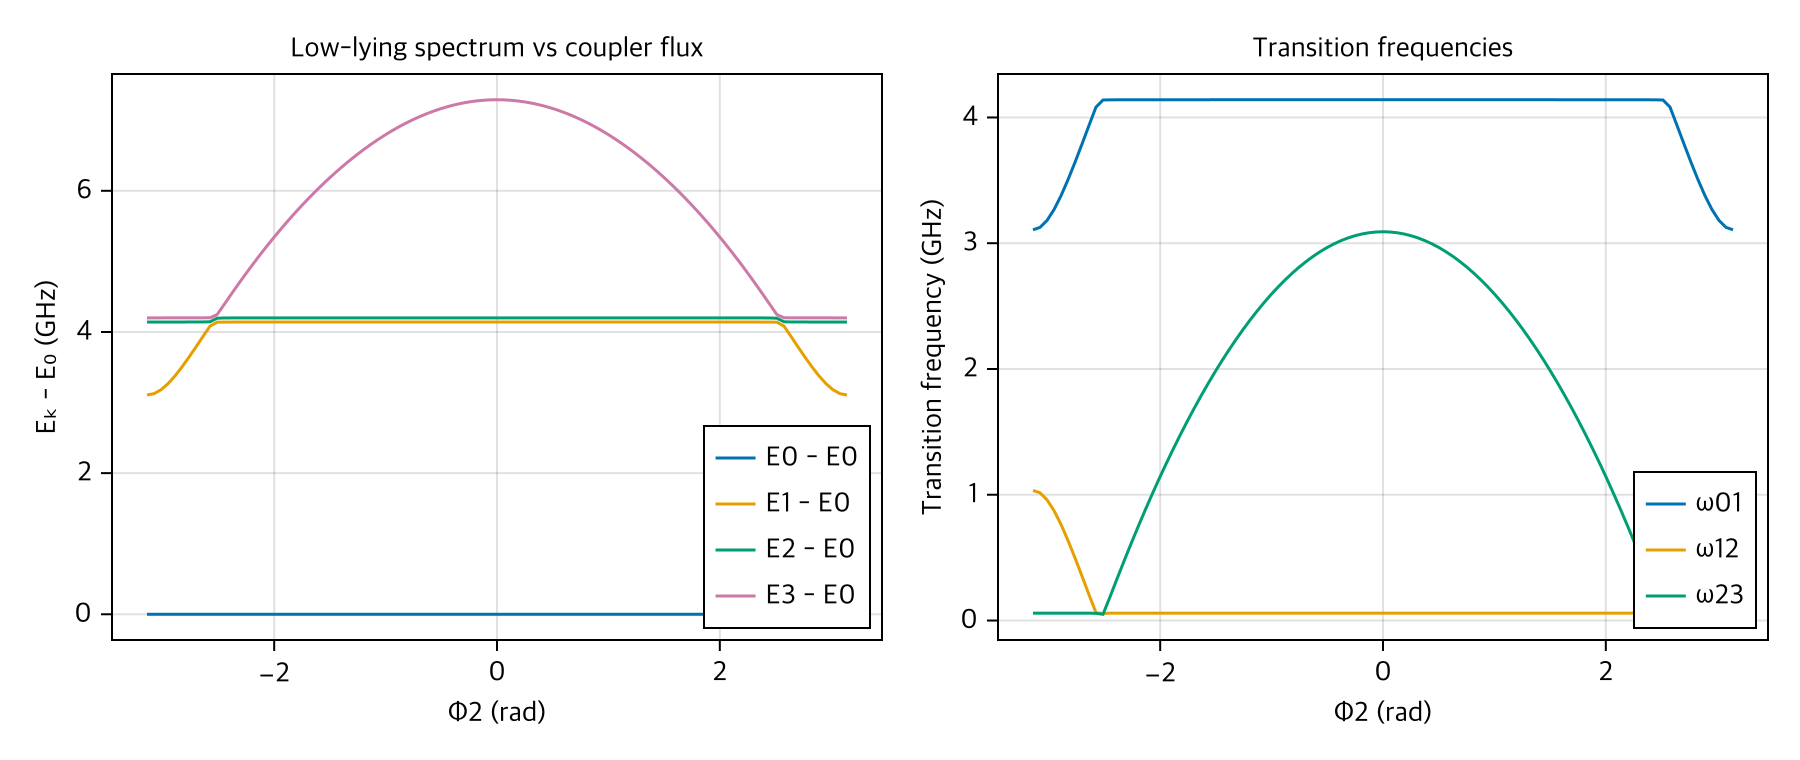

In [22]:
fig = Figure(size=(900, 380))

ax1 = Axis(fig[1, 1],
    xlabel="Φ2 (rad)",
    ylabel="Eₖ - E₀ (GHz)",
    title="Low-lying spectrum vs coupler flux")

for k in 1:size(relative_levels, 2)
    lines!(ax1, φ2_vals, relative_levels[:, k], label="E$(k-1) - E0")
end
axislegend(ax1, position=:rb)

ax2 = Axis(fig[1, 2],
    xlabel="Φ2 (rad)",
    ylabel="Transition frequency (GHz)",
    title="Transition frequencies")
lines!(ax2, φ2_vals, transitions[:, 1], label="ω01")
lines!(ax2, φ2_vals, transitions[:, 2], label="ω12")
lines!(ax2, φ2_vals, transitions[:, 3], label="ω23")
axislegend(ax2, position=:rb)

fig


## Hierarchical Subsystem Sweep

The figure above shows the **collective** low-lying spectrum of the fully coupled circuit. To mimic the subsystem-resolved plot used in the Yan-style coupler literature, we instead partition the three periodic modes into `QB1`, `CPLR`, and `QB2` and extract each subsystem's `|0⟩ → |1⟩` transition from a hierarchical decomposition.

Here we keep `Φ1 = Φ3 = 0`, sweep only the coupler bias `Φ2`, and convert the horizontal axis to normalized flux units `Φ2 / (2π)` so it is displayed in units of `Φ₀`. In this notebook, `configure!` is the stateful symbolic-analysis interface, while `hierarchical_diag(...)` remains the sweep-oriented numerical interface for repeatedly extracting subsystem frequencies.


In [23]:
φ2_vals_hier = collect(range(-π, π; length=51))
flux_bias = φ2_vals_hier ./ (2π)

qb1_w01 = Float64[]
cplr_w01 = Float64[]
qb2_w01 = Float64[]

for φ2 in φ2_vals_hier
    circ_hier = Circuit(tcap_coupled_tmon; ncut=6)
    set_param!(circ_hier, :Φ1, 0.0)
    set_param!(circ_hier, :Φ2, φ2)
    set_param!(circ_hier, :Φ3, 0.0)

    hs_hier = hierarchical_diag(circ_hier;
        system_hierarchy=[[1], [2], [3]],
        subsystem_trunc_dims=[3, 3, 3])

    qb1 = hs_hier.subsystems[1]
    cplr = hs_hier.subsystems[2]
    qb2 = hs_hier.subsystems[3]

    push!(qb1_w01, eigenvals(qb1; evals_count=2)[2] - eigenvals(qb1; evals_count=2)[1])
    push!(cplr_w01, eigenvals(cplr; evals_count=2)[2] - eigenvals(cplr; evals_count=2)[1])
    push!(qb2_w01, eigenvals(qb2; evals_count=2)[2] - eigenvals(qb2; evals_count=2)[1])
end

println("Hierarchical sweep points: ", length(φ2_vals_hier))
println("Center frequencies (QB1, CPLR, QB2): ",
    (qb1_w01[26], cplr_w01[26], qb2_w01[26]))


Hierarchical sweep points: 51
Center frequencies (QB1, CPLR, QB2): (4.199717201812376, 7.290541160358643, 4.140973618765223)


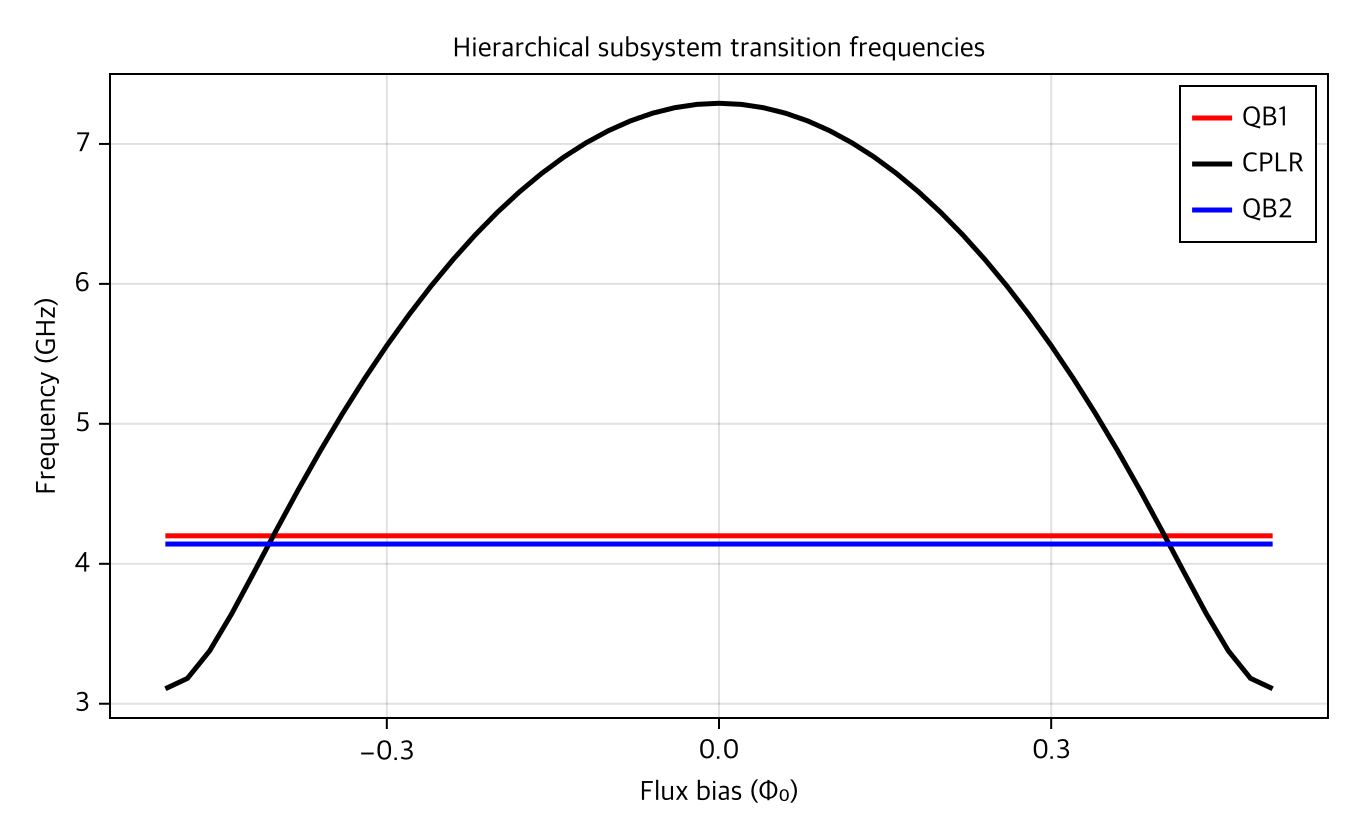

In [24]:
fig_hier = Figure(size=(680, 420))
ax_hier = Axis(fig_hier[1, 1],
    xlabel="Flux bias (Φ₀)",
    ylabel="Frequency (GHz)",
    title="Hierarchical subsystem transition frequencies")

lines!(ax_hier, flux_bias, qb1_w01, color=:red, linewidth=2.5, label="QB1")
lines!(ax_hier, flux_bias, cplr_w01, color=:black, linewidth=2.5, label="CPLR")
lines!(ax_hier, flux_bias, qb2_w01, color=:blue, linewidth=2.5, label="QB2")
axislegend(ax_hier, position=:rt)

fig_hier


## Hierarchical Diagonalization and Subsystem Interactions

The low-lying spectrum above comes from full direct diagonalization of the complete circuit Hamiltonian. The configured subsystem section uses `configure!` together with `sym_hamiltonian(...; subsystem_index=...)` and `sym_interaction(...; subsystem_indices=(i, j, ...))` to inspect symbolic subsystem structure and subsystem-set couplings.

For subsystem-resolved quantities such as the paper-style `QB1 / CPLR / QB2` transition-frequency plot, this repo also supports `hierarchical_diag(...)` with one subsystem per periodic mode.


## Visualization Capabilities

The remaining visualization gaps versus the scqubits example are still limited to `Circuit`-specific plotting helpers:

- `plot_potential`
- `Circuit` wavefunction plotting
